# 0 &middot; Discretizing a Deformation &mdash; the Finite Element Method

Here is a smooth, recognizable shape. Suppose we ask the most basic question in
all of solid mechanics:

> **how does this shape deform?**

To answer it we need, at *every* material point \(\bar x\) of the rest shape, a
**displacement** telling us where that point goes. Collecting all of those
displacements gives a **deformation map**
$$ \phi(\bar x) = \bar x + u(\bar x), $$
where \(u(\bar x)\) is the displacement field. The picture below shows the rest
shape and one possible deformed shape &mdash; both drawn as smooth, continuous
blobs (no triangles in sight... yet).

This first tutorial is about a single, foundational idea: **a computer cannot
store \(u\) at infinitely many points, so we have to discretize it.** The
*finite element method* (FEM) is the classic way to do that for elastic PDEs,
and everything in the tutorials that follow is built on top of it.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.collections import PolyCollection
from matplotlib.patches import Polygon
from matplotlib.path import Path
from matplotlib.animation import FuncAnimation
from scipy.spatial import Delaunay        # a general triangulator -- NOT a mesh file, NOT igl
import simkit
import utils
os.makedirs("media", exist_ok=True)

HEART_FACE = "#fbb4b9"    # soft pink fill
HEART_EDGE = "#c51b8a"    # magenta edges / arrows

/Users/otmanbench/simkit/simkit/__init__.py:205: UserWarning: simkit: some functionality is unavailable because optional dependencies are not installed:
  [cmaes] (missing: simkit.solvers.NewtonSolver) -> pip install 'simkit[cmaes]'
  [other] (missing: simkit.solvers.NewtonSolver) -> pip install 'simkit[all]'
  _emit_missing_warning()


## A shape we build ourselves

No mesh files here: we **define the shape analytically** with the classic heart
curve
$$ x(t) = 16\sin^3 t,\qquad
   y(t) = 13\cos t - 5\cos 2t - 2\cos 3t - \cos 4t, $$
and then build a triangle mesh for its interior ourselves with a generic
Delaunay triangulator (no meshing library, no `igl`): scatter points inside the
outline, triangulate them, and throw away any triangle whose centre falls
outside the heart.

For the deformation we pick something simple and recognizable: a gentle **bend**
that curls the heart about its vertical axis. It is an *analytic* map \(\phi\)
&mdash; we can evaluate the true displacement \(u(\bar x) = \phi(\bar x) - \bar x\)
at **any** point we like. That is exactly the luxury a computer does *not* have.

a smooth heart: 3238 points, 6026 triangles


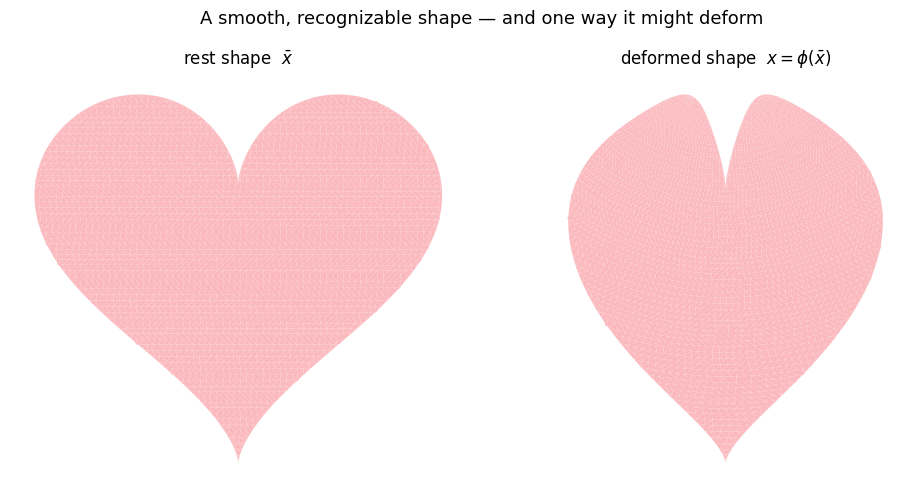

In [2]:
def heart_outline(n):
    """n points around the analytic heart curve, normalized into [-1, 1]^2."""
    t = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    x = 16.0 * np.sin(t) ** 3
    y = 13.0 * np.cos(t) - 5.0 * np.cos(2 * t) - 2.0 * np.cos(3 * t) - np.cos(4 * t)
    P = np.column_stack([x, y]).astype(float)
    P -= 0.5 * (P.max(0) + P.min(0))          # centre the bounding box at the origin
    P /= np.abs(P).max()                       # scale into [-1, 1]
    return P

def triangulate_heart(n_boundary, spacing):
    """A triangle mesh of the heart's interior, built with Delaunay + a point-in-shape test."""
    B = heart_outline(n_boundary)
    region = Path(B)
    g = np.arange(-1.0, 1.0 + 1e-9, spacing)            # a grid of candidate interior points
    XX, YY = np.meshgrid(g, g)
    P = np.column_stack([XX.ravel(), YY.ravel()])
    jit = np.linspace(0.0, 1.0, len(P))                 # tiny deterministic jitter -> nicer triangles
    P = P + (spacing * 0.18) * np.column_stack([np.sin(53 * jit), np.cos(37 * jit)])
    P = P[region.contains_points(P, radius=-0.45 * spacing)]   # keep points safely inside
    pts = np.vstack([B, P])
    F = Delaunay(pts).simplices
    F = F[region.contains_points(pts[F].mean(1))]       # drop triangles outside the heart
    return pts, F

# A simple, recognizable deformation  phi(x) = x + u(x):  bend about the vertical axis x = 0.
def deform(P, k=0.7):
    """The TRUE smooth deformation map phi, evaluable at any points P. Curvature k."""
    P = np.asarray(P, float)
    if abs(k) < 1e-9:
        return P.copy()
    R = 1.0 / k
    s = P[:, 0]               # position along the bending axis (heart is centred at x=0)
    h = P[:, 1]               # height above the axis
    theta = s / R             # bend angle grows with arc length
    r = R - h
    return np.column_stack([r * np.sin(theta), R - r * np.cos(theta)])

def show_shape(ax, U, Tris, *, edges=False, title="", face=HEART_FACE, lw=0.5):
    """Fill a triangle mesh. With edges=False it looks like a smooth continuous blob."""
    ec = HEART_EDGE if edges else "none"
    ax.add_collection(PolyCollection([U[f] for f in Tris], facecolors=face,
                                     edgecolors=ec, linewidths=(lw if edges else 0.0),
                                     alpha=0.95))
    ax.set_aspect("equal"); ax.autoscale(); ax.margins(0.06); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12)

X, T = triangulate_heart(n_boundary=360, spacing=0.028)    # a fine mesh for the smooth look
print(f"a smooth heart: {X.shape[0]} points, {T.shape[0]} triangles")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
show_shape(axes[0], X, T, title=r"rest shape  $\bar{x}$")
show_shape(axes[1], deform(X), T, title=r"deformed shape  $x = \phi(\bar{x})$")
fig.suptitle("A smooth, recognizable shape — and one way it might deform", fontsize=13)
fig.tight_layout(); fig.savefig("media/00_teaser.png", dpi=130, bbox_inches="tight")
plt.show()

## The deformation *is* a vector field

The deformation map carries one piece of information at every point: a little
arrow \(u(\bar x)\) saying which way, and how far, that material point moves.
Drawing those arrows on the rest shape gives the **displacement vector field**.
Near the bottom tip the arrows are tiny (that part barely moves); up at the
lobes they sweep inward and up as the heart curls.

Finding this field \(u\) &mdash; one arrow per point &mdash; *is* the problem we
want to solve.

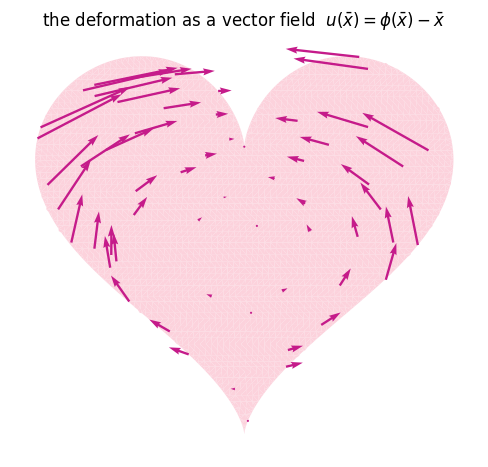

In [3]:
U_def = deform(X)
disp = U_def - X
idx = np.arange(0, X.shape[0], 55)          # subsample so the arrows are readable

fig, ax = plt.subplots(figsize=(6.5, 5.5))
show_shape(ax, X, T, face="#fcd0db",
           title=r"the deformation as a vector field  $u(\bar{x}) = \phi(\bar{x}) - \bar{x}$")
ax.quiver(X[idx, 0], X[idx, 1], disp[idx, 0], disp[idx, 1], angles="xy",
          scale_units="xy", scale=1, color=HEART_EDGE, width=0.005, zorder=5)
fig.savefig("media/00_field.png", dpi=130, bbox_inches="tight")
plt.show()


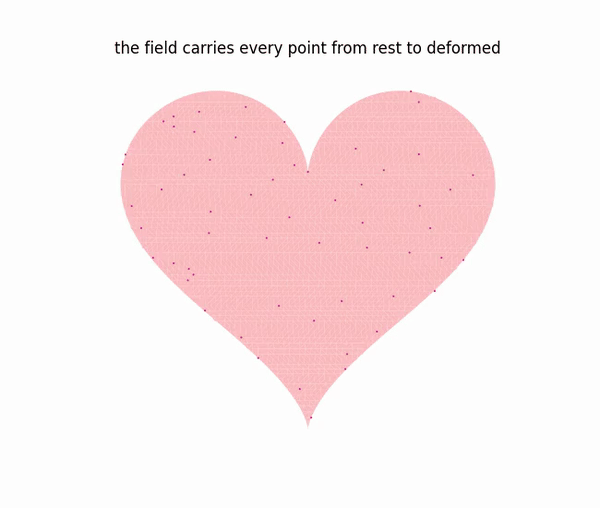

In [4]:
# Watch the field "push" the shape from rest to deformed (the arrows grow with it).
frames = 36
ts = 0.5 * (1 - np.cos(np.linspace(0, np.pi, frames)))   # smooth ease 0 -> 1
states = [X + t * disp for t in ts]
(xlim, ylim) = utils.auto_limits(states, pad=0.12)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.set_aspect("equal"); ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis("off")
ax.set_title("the field carries every point from rest to deformed", fontsize=12)
mesh = utils.PolyMeshArtist(ax, states[0], T, facecolor=HEART_FACE, edgecolor="none")
q = ax.quiver(X[idx, 0], X[idx, 1], 0 * disp[idx, 0], 0 * disp[idx, 1], angles="xy",
              scale_units="xy", scale=1, color=HEART_EDGE, width=0.005, zorder=5)

def update(i):
    mesh.update(states[i])
    q.set_UVC(ts[i] * disp[idx, 0], ts[i] * disp[idx, 1])
    return ()

anim = FuncAnimation(fig, update, frames=frames, interval=1000 / 20, blit=False)
utils.save_anim(anim, "media/00_morph.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## The catch: there are infinitely many points

A smooth shape has a *continuum* of material points. We cannot ask a computer to
find \(u(\bar x)\) at infinitely many \(\bar x\) &mdash; we need a finite list of
unknowns.

This is what the **finite element method** does, and the idea is wonderfully
simple:

1. **Triangulate** the shape into a mesh of triangles (the *elements*).
2. Store the displacement \(u\) **only at the vertices** &mdash; a finite set of
   unknowns.
3. To get \(u\) **anywhere else**, *interpolate* the surrounding vertex values
   across the triangle.

So the whole continuous field collapses down to a handful of arrows, one per
vertex. Everything in between is reconstructed by interpolation.

coarse FEM mesh: 50 vertices, 64 triangles
we will only ever solve for u at those vertices.


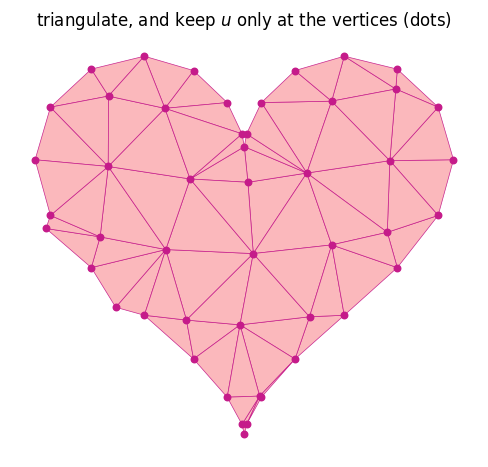

In [4]:
# A deliberately COARSE mesh of the same heart, so the elements are big and visible.
Xc, Tc = triangulate_heart(n_boundary=28, spacing=0.34)
print(f"coarse FEM mesh: {Xc.shape[0]} vertices, {Tc.shape[0]} triangles")
print("we will only ever solve for u at those vertices.")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
show_shape(ax, Xc, Tc, edges=True,
           title="triangulate, and keep $u$ only at the vertices (dots)")
used = np.unique(Tc)                                   # only vertices that belong to a triangle
ax.scatter(Xc[used, 0], Xc[used, 1], s=22, color=HEART_EDGE, zorder=6)
fig.savefig("media/00_mesh.png", dpi=130, bbox_inches="tight")
plt.show()

## Inside one triangle: barycentric interpolation

How do we reconstruct \(u\) *inside* a triangle from its three corner values?
Every point \(\bar x\) in a triangle with corners \(\bar x_0, \bar x_1,
\bar x_2\) has a unique set of **barycentric coordinates**
\((\lambda_0, \lambda_1, \lambda_2)\) with
$$ \bar x = \lambda_0 \bar x_0 + \lambda_1 \bar x_1 + \lambda_2 \bar x_2,
\qquad \lambda_0 + \lambda_1 + \lambda_2 = 1,\quad \lambda_i \ge 0. $$
The \(\lambda_i\) are also the **linear (P1) basis functions** \(\phi_i\) of the
triangle. Each one equals \(1\) at its own vertex, \(0\) at the other two, and
varies linearly in between. Below each \(\phi_i\) is drawn flat, **as a color**
over the triangle (bright \(= 1\) at its vertex, dark \(= 0\) at the others).

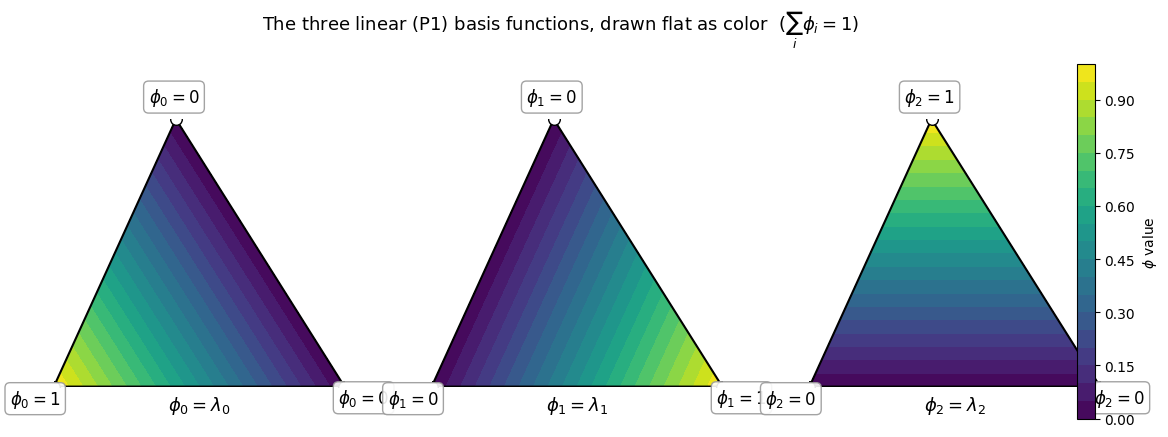

In [5]:
def barycentric(p, V):
    """Barycentric coords (lambda0, lambda1, lambda2) of point p in triangle V (3x2)."""
    M = np.array([[V[0, 0] - V[2, 0], V[1, 0] - V[2, 0]],
                  [V[0, 1] - V[2, 1], V[1, 1] - V[2, 1]]])
    a, b = np.linalg.solve(M, np.asarray(p, float) - V[2])
    return np.array([a, b, 1.0 - a - b])

# A single triangle, finely sampled inside; color each point by phi_i = lambda_i.
Vtri = np.array([[0.0, 0.0], [1.0, 0.0], [0.42, 0.92]])
m = 80
pts, lam = [], []
for i in range(m + 1):
    for j in range(m + 1 - i):
        a, b = i / m, j / m
        c = 1.0 - a - b
        pts.append(a * Vtri[0] + b * Vtri[1] + c * Vtri[2])
        lam.append((a, b, c))
pts = np.array(pts); lam = np.array(lam)
tri = mtri.Triangulation(pts[:, 0], pts[:, 1])
centroid = Vtri.mean(0)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for k in range(3):
    ax = axes[k]
    tcf = ax.tricontourf(tri, lam[:, k], levels=np.linspace(0, 1, 21), cmap="viridis")
    ax.plot([Vtri[0, 0], Vtri[1, 0], Vtri[2, 0], Vtri[0, 0]],
            [Vtri[0, 1], Vtri[1, 1], Vtri[2, 1], Vtri[0, 1]], "k", lw=1.5)
    for v in range(3):                                  # value label, nudged outward from the centre
        d = Vtri[v] - centroid; d = d / np.linalg.norm(d)
        ax.scatter(*Vtri[v], s=70, color="white", edgecolor="k", zorder=5)
        ax.annotate(rf"$\phi_{k}={1 if v == k else 0}$", Vtri[v], textcoords="offset points",
                    xytext=(16 * d[0], 16 * d[1]), ha="center", va="center", fontsize=12, zorder=6,
                    bbox=dict(boxstyle="round", fc="white", ec="0.6", alpha=0.9))
    ax.set_title(rf"$\phi_{k} = \lambda_{k}$", y=-0.12, fontsize=13)
    ax.set_aspect("equal"); ax.axis("off"); ax.margins(0.22)
cb = fig.colorbar(tcf, ax=axes, fraction=0.022, pad=0.06); cb.set_label(r"$\phi$ value")
fig.suptitle(r"The three linear (P1) basis functions, drawn flat as color  ($\sum_i \phi_i = 1$)",
             fontsize=13, y=1.0)
fig.subplots_adjust(top=0.84, bottom=0.1, wspace=0.3)
fig.savefig("media/00_hats.png", dpi=130, bbox_inches="tight")
plt.show()

## Combining the hats into a *vector* interpolation

Now give each corner its own displacement **vector** \(u_0, u_1, u_2\). The
displacement at any interior point is the basis-weighted blend
$$ u(\bar x) = \sum_{i} \phi_i(\bar x)\, u_i
            = \lambda_0 u_0 + \lambda_1 u_1 + \lambda_2 u_2. $$
So the value at the three vertices is all we store; the arrow everywhere else is
reconstructed from them. Watch the evaluation point (orange) sweep across the
triangle: its arrow continuously rebalances between the three corner arrows
(blue), and **as it approaches a vertex, \(\lambda\) collapses onto that vertex
and the interpolated arrow matches the vertex's own arrow exactly.**


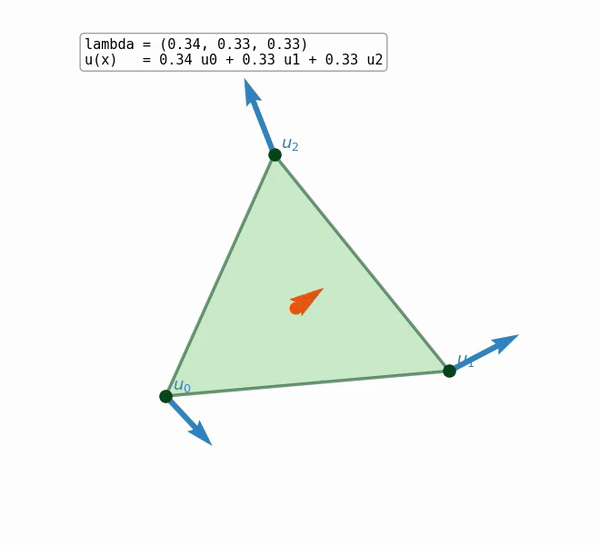

In [10]:
Vtri = np.array([[0.0, 0.0], [1.7, 0.15], [0.65, 1.45]])     # a generic triangle
Uv   = np.array([[0.28, -0.30], [0.42, 0.22], [-0.18, 0.46]])  # one vector per corner

# A path (in barycentric weights) that lingers near each corner, then the centre.
key = np.array([[0.34, 0.33, 0.33],
                [0.86, 0.07, 0.07],     # near corner 0
                [0.34, 0.33, 0.33],
                [0.07, 0.86, 0.07],     # near corner 1
                [0.34, 0.33, 0.33],
                [0.07, 0.07, 0.86],     # near corner 2
                [0.34, 0.33, 0.33]])
seg = 26
path_bary = np.vstack([np.linspace(key[i], key[i + 1], seg, endpoint=False)
                       for i in range(len(key) - 1)])
path_xy = path_bary @ Vtri                                     # the moving point x

fig, ax = plt.subplots(figsize=(6.6, 6.0))
ax.add_patch(Polygon(Vtri, closed=True, facecolor=utils.TRI_FACE,
                     edgecolor=utils.TRI_EDGE, lw=2.5, alpha=0.55, zorder=1))
for i in range(3):                                             # the fixed corner arrows
    ax.quiver(Vtri[i, 0], Vtri[i, 1], Uv[i, 0], Uv[i, 1], angles="xy",
              scale_units="xy", scale=1, color=utils.PIN_C, width=0.012, zorder=4)
    ax.scatter(*Vtri[i], s=90, color=utils.TRI_EDGE, zorder=5)
    ax.annotate(rf"$u_{i}$", Vtri[i] + np.array([0.04, 0.04]), fontsize=13,
                color=utils.PIN_C)
ax.set_aspect("equal"); ax.autoscale(); ax.margins(0.32); ax.axis("off")

q_pt = ax.quiver(path_xy[0, 0], path_xy[0, 1], 0, 0, angles="xy", scale_units="xy",
                 scale=1, color=utils.HANDLE_C, width=0.015, zorder=7)
dot, = ax.plot([], [], "o", color=utils.HANDLE_C, ms=9, zorder=8)
txt = ax.text(0.02, 1.1, "", transform=ax.transAxes, va="top", family="monospace",
              fontsize=11, bbox=dict(boxstyle="round", fc="white", ec="0.6", alpha=0.9))

def update(i):
    p = path_xy[i]
    lam = barycentric(p, Vtri)            # recovered from the position alone
    u = lam @ Uv                          # u(x) = sum lambda_i u_i
    q_pt.set_offsets(p); q_pt.set_UVC(u[0], u[1])
    dot.set_data([p[0]], [p[1]])
    txt.set_text(f"lambda = ({lam[0]:.2f}, {lam[1]:.2f}, {lam[2]:.2f})\n"
                 f"u(x)   = {lam[0]:.2f} u0 + {lam[1]:.2f} u1 + {lam[2]:.2f} u2")
    return ()

anim = FuncAnimation(fig, update, frames=len(path_xy), interval=1000 / 20, blit=False)
utils.save_anim(anim, "media/00_interp.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## The whole shape: it was triangles all along

Apply this to every triangle at once. We sample the displacement **only at the
coarse vertices**, then let each triangle interpolate its three corner vectors
across its interior. That is a full finite-element deformation &mdash; no
solver, no energy, just *store-at-vertices + interpolate-inside*.

Now turn the triangle edges back **on**. The smooth deforming heart from the
very first cell was a triangle mesh the entire time; we just never drew its
edges. As we refine the mesh, the piecewise-linear approximation marches back
toward the smooth limit you saw at the start.

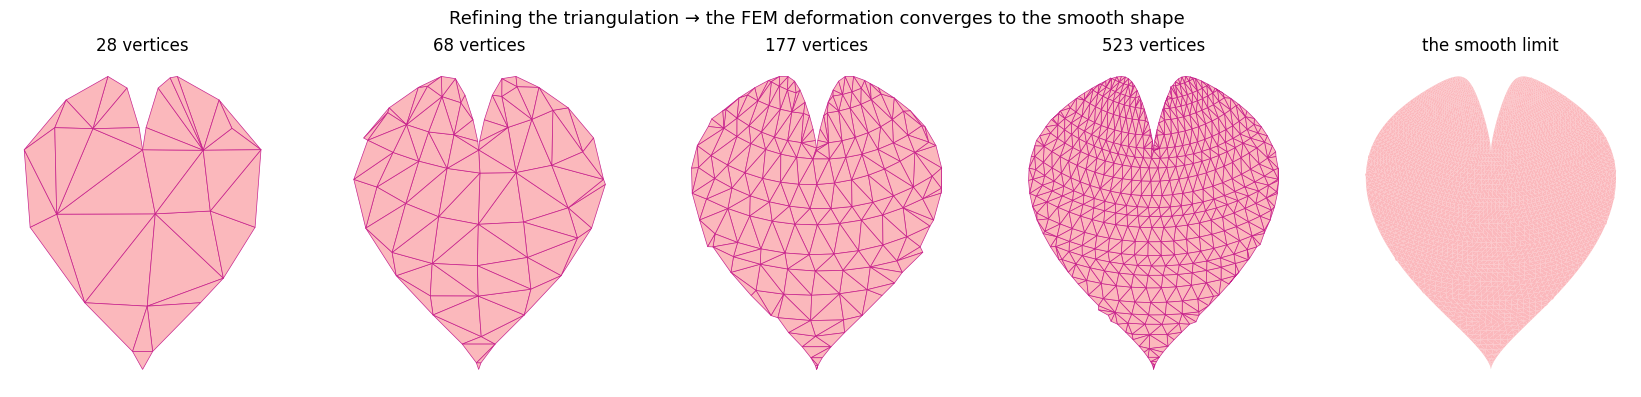

In [8]:
# Refine the mesh from very coarse to fine; deform each by sampling u at its vertices.
levels = [(18, 0.5), (30, 0.26), (55, 0.14), (110, 0.075)]
meshes = [triangulate_heart(nb, sp) for (nb, sp) in levels]

fig, axes = plt.subplots(1, len(meshes) + 1, figsize=(3.4 * (len(meshes) + 1), 4))
for ax, (V, F) in zip(axes, meshes):
    show_shape(ax, deform(V), F, edges=True, title=f"{V.shape[0]} vertices")
show_shape(axes[-1], deform(X), T, edges=False, title="the smooth limit")
fig.suptitle("Refining the triangulation → the FEM deformation converges to the smooth shape",
             fontsize=13)
fig.tight_layout(); fig.savefig("media/00_convergence.png", dpi=130, bbox_inches="tight")
plt.show()

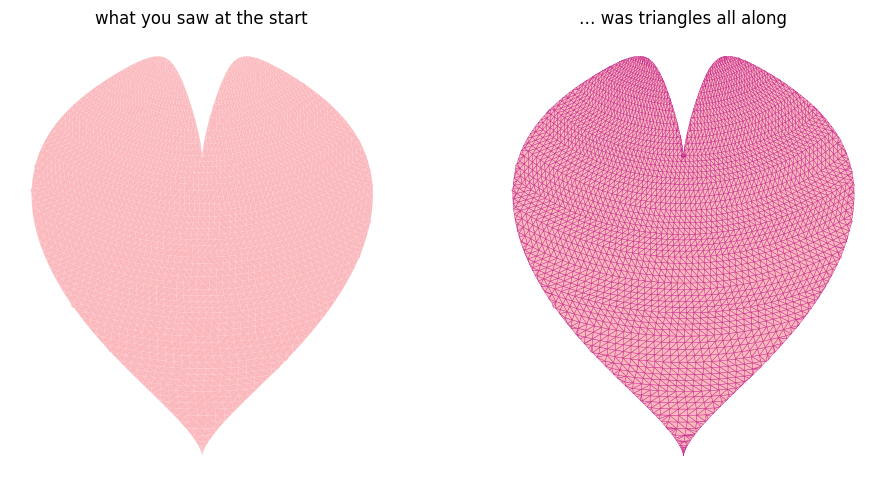

In [7]:
# The reveal: the same fine teaser heart, edges off vs edges on.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
show_shape(axes[0], deform(X), T, edges=False, title="what you saw at the start")
show_shape(axes[1], deform(X), T, edges=True, lw=0.3,
           title="… was triangles all along")
fig.tight_layout(); fig.savefig("media/00_reveal.png", dpi=130, bbox_inches="tight")
plt.show()

### Takeaways

* The question "how does this shape deform?" is a request for a **displacement
  field** \(u(\bar x)\), i.e. one arrow per material point.
* A computer can't carry infinitely many arrows, so we **discretize**. The
  **finite element method** triangulates the shape, stores \(u\) **only at the
  vertices**, and reconstructs it everywhere else by **barycentric interpolation**
  with the linear basis functions \(\phi_i\):
  \(\,u(\bar x) = \sum_i \phi_i(\bar x)\, u_i.\)
* Inside each triangle the deformation is just a linear blend of three corner
  vectors &mdash; the same blend we animated, applied everywhere at once.
* Refine the mesh and the piecewise-linear field converges to the smooth one.
  The smooth teaser really was triangles the whole time.

With this foundation &mdash; *how to represent a deformation on a computer* &mdash;
the rest of the tutorials build up the pipeline: measuring how stretched each
element is (the **deformation gradient**, tutorial 1), turning that into an
**elastic energy**, and **minimizing** it to actually *find* the deformation.

> **FEM is not the only way.** Triangle/tet meshes are the classic choice, but
> they are one of many ways to discretize geometry and the fields living on it:
> **Gaussian splats**, **RKPM** and other meshless/particle methods, **point
> clouds**, **signed distance fields**, subdivision and spline patches, neural
> fields, and more. Each trades off smoothness, ease of meshing, adaptivity, and
> cost differently &mdash; and choosing the right discretization for a given
> geometry remains an active, open research problem.